<a href="https://colab.research.google.com/github/veronicaagunbiade-cmyk/CodeAlpha-Data-Science-Internship/blob/main/Iris_Flower_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Iris Flower Classification Using Machine Learning

## Project Objective

The objective of this project is to develop a machine learning classification model capable of identifying iris flower species based on their sepal and petal measurements. The project demonstrates the use of supervised machine learning techniques for classification tasks.

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Iris.csv to Iris.csv


## Import Libraries

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

## Load Dataset

In [4]:
df = pd.read_csv('Iris.csv')

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## Data Exploration

In [5]:
df.shape

(150, 6)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [7]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [8]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


## Data Preprocessing

In [9]:
df.drop('Id', axis=1, inplace=True)

df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Exploratory Data Analysis (EDA)

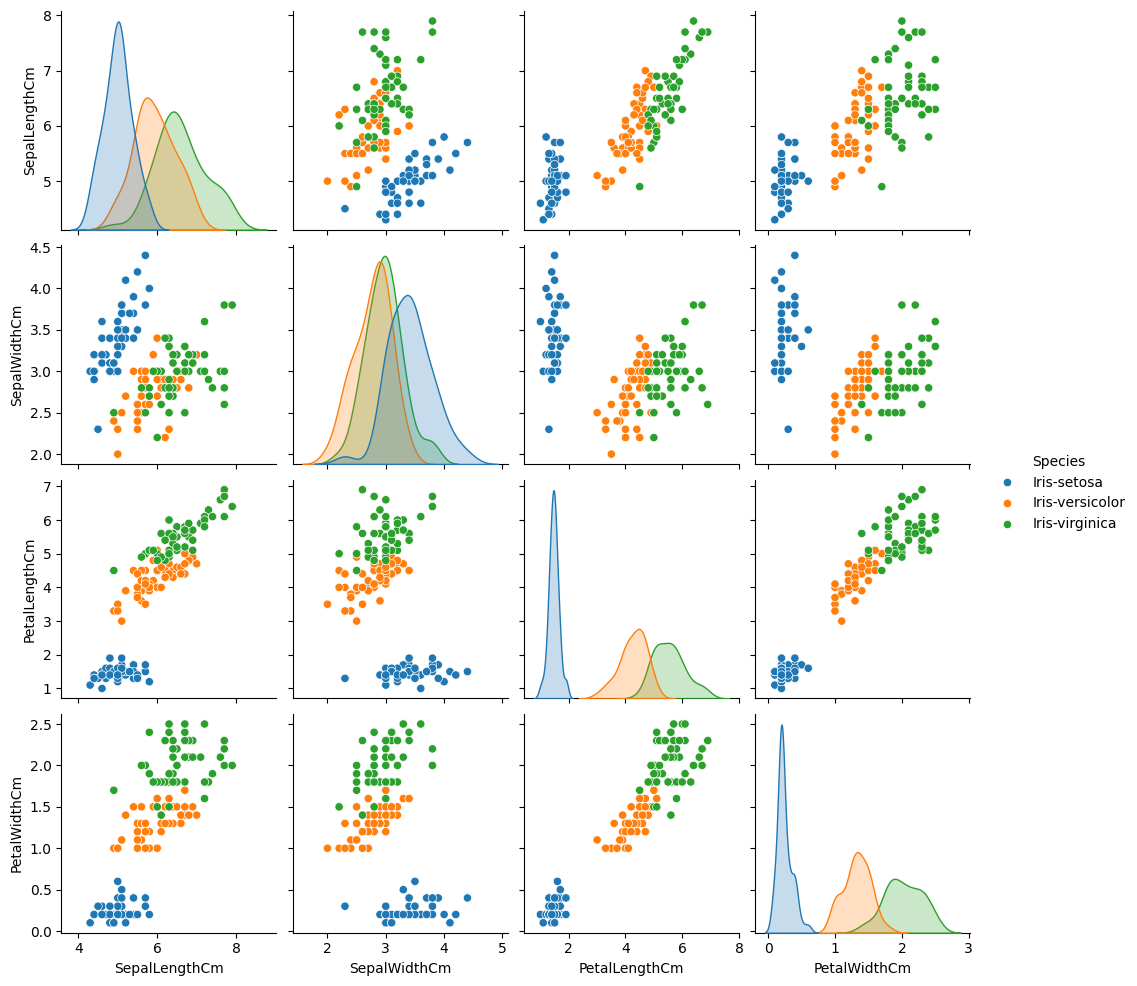

In [10]:
sns.pairplot(
    df,
    hue='Species'
)

plt.show()

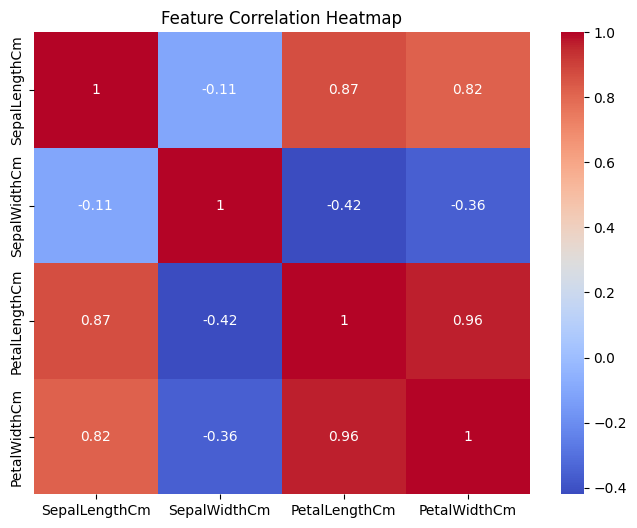

In [11]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.drop('Species', axis=1).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Feature Correlation Heatmap')

plt.show()

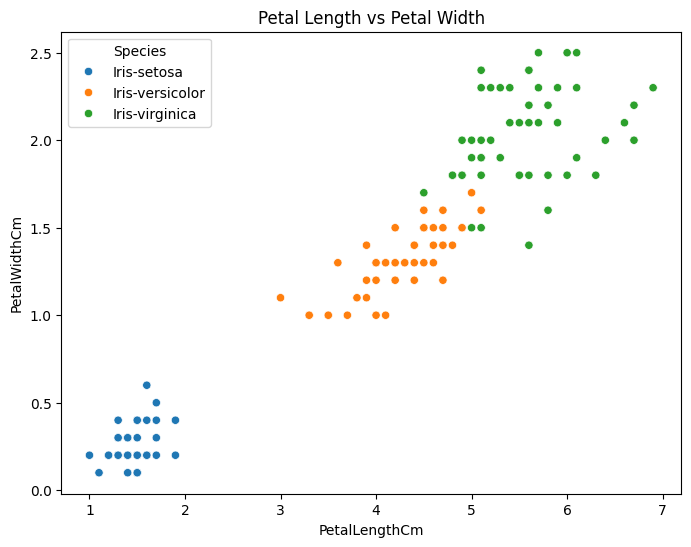

In [12]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='PetalLengthCm',
    y='PetalWidthCm',
    hue='Species'
)

plt.title(
    'Petal Length vs Petal Width'
)

plt.show()

## Model Training

In [13]:
X = df.drop(
    'Species',
    axis=1
)

y = df['Species']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

## Model Evaluation

In [16]:
y_pred = model.predict(X_test)

In [17]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    accuracy
)

Accuracy: 1.0


In [18]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



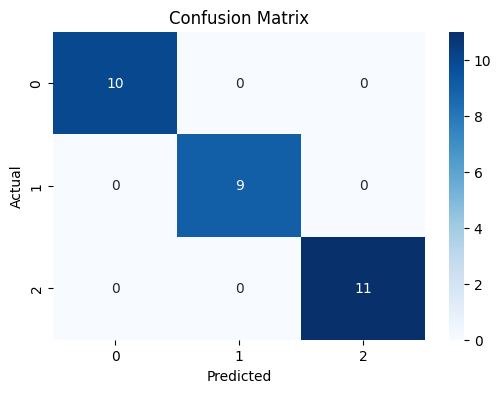

In [19]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'Confusion Matrix'
)

plt.xlabel(
    'Predicted'
)

plt.ylabel(
    'Actual'
)

plt.show()

## Prediction

In [21]:
sample = pd.DataFrame({
    'SepalLengthCm': [5.1],
    'SepalWidthCm': [3.5],
    'PetalLengthCm': [1.4],
    'PetalWidthCm': [0.2]
})

prediction = model.predict(sample)

print(
    "Predicted Species:",
    prediction[0]
)

Predicted Species: Iris-setosa


## Key Insights

### Findings

1. Petal length and petal width were the most important features for distinguishing iris species.

2. Setosa was the easiest species to classify because its characteristics were clearly distinct from the other species.

3. Versicolor and Virginica showed some overlap but were still classified accurately.

4. Feature relationships revealed strong correlations among petal measurements.

5. The Random Forest model achieved high classification accuracy, demonstrating the effectiveness of supervised learning for classification tasks.

## Conclusion

This project developed a machine learning classification model capable of identifying iris flower species using sepal and petal measurements. The dataset was explored, visualized, and preprocessed before training a Random Forest Classifier.

The model achieved high classification accuracy and successfully distinguished between Iris-setosa, Iris-versicolor, and Iris-virginica species. The analysis highlighted the importance of petal dimensions in species classification and demonstrated the effectiveness of machine learning techniques for biological classification problems.

This project successfully showcased the complete machine learning workflow, including data exploration, visualization, preprocessing, model training, evaluation, and prediction.